## Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore", message="invalid value encountered")

### Investigated Features

In [2]:
# Data preparation
data = pd.read_csv("df_train.csv")
data["date"] = pd.to_datetime(data["date"])
data = data.sort_values(["symbol", "date"]).reset_index(drop=True)

# --- Feature engineering (group by symbol) ---
g = data.groupby("symbol")

# Daily returns and target
data["daily_ret"] = g["close"].pct_change()
data["target"] = g["close"].shift(-1) / data["close"] - 1

# Single-day price features
data["intraday_ret"] = (data["close"] - data["open"]) / data["open"]
data["range_price"] = (data["high"] - data["low"]) / data["open"]
data["close_position"] = np.where(
    data["high"] == data["low"],
    0.5,
    (data["close"] - data["low"]) / (data["high"] - data["low"]),
)

# Volume
data["vol_change"] = g["volume"].pct_change()
data["avg_volume_20d"] = g["volume"].transform(
    lambda s: s.rolling(20, min_periods=20).mean()
)
data["volume_surprise"] = data["volume"] / data["avg_volume_20d"]

# Momentum
data["mom_5d"] = data["close"] / g["close"].shift(5) - 1
data["mom_10d"] = data["close"] / g["close"].shift(10) - 1

# Volatility
data["vol_5d"] = g["daily_ret"].transform(
    lambda s: s.rolling(5, min_periods=5).std()
)
data["vol_10d"] = g["daily_ret"].transform(
    lambda s: s.rolling(10, min_periods=10).std()
)

# Short-term reversal
data["reversal_1d"] = -g["daily_ret"].shift(1)
data["reversal_5d"] = (
    data["close"]
    / g["close"].transform(lambda s: s.rolling(5, min_periods=5).mean())
    - 1
)
data["reversal_10d"] = (
    data["close"]
    / g["close"].transform(lambda s: s.rolling(10, min_periods=10).mean())
    - 1
)

# Return-volume interaction
data["ret_vol"] = data["daily_ret"] * data["volume_surprise"]

# Overnight return
data["overnight_ret"] = data["open"] / data.groupby("symbol")["close"].shift(1) - 1

# Volatility-adjusted momentum
data["mom_10d_vol_adj"] = data["mom_10d"] / data["vol_10d"]
data["mom_5d_vol_adj"] = data["mom_5d"] / data["vol_5d"]

# RSI (14-day)
def rsi(series, n=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(n).mean()
    loss = (-delta.clip(upper=0)).rolling(n).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - 100 / (1 + rs)

data["rsi_14"] = g["close"].transform(lambda x: rsi(x, 14))

# Moving averages & crossover
data["sma_5"] = g["close"].transform(lambda x: x.rolling(5).mean())
data["sma_20"] = g["close"].transform(lambda x: x.rolling(20).mean())
data["sma_cross"] = data["sma_5"] / data["sma_20"] - 1

# Close location in daily range (same as close_position but without the 0.5 fill)
data["close_loc"] = (data["close"] - data["low"]) / (data["high"] - data["low"])

# --- Cross-sectional ranks (group by date) ---
data["mom_5d_rank"] = data.groupby("date")["mom_5d"].rank(pct=True)
data["volume_surprise_rank"] = data.groupby("date")["volume_surprise"].rank(pct=True)

# --- Interaction features (filtered subset) ---
df_interaction = (
    data
    .dropna(subset=["daily_ret", "vol_5d", "target"])
    .copy()
)
df_interaction["vol_regime"] = (
    df_interaction
    .groupby("date")["vol_5d"]
    .transform(lambda s: np.where(s > s.median(), "high_vol", "low_vol"))
)
df_interaction["ret_quintile"] = (
    df_interaction
    .groupby("date")["daily_ret"]
    .transform(lambda s: pd.qcut(s, 5, labels=False, duplicates="drop") + 1)
)

In [3]:
# Correlation
feature_names = [
    # Single-day price features
    "intraday_ret", "range_price", "close_position",
    # Volume
    "vol_change", "volume_surprise",
    # Momentum
    "mom_5d", "mom_10d",
    # Volatility
    "vol_5d", "vol_10d",
    # Short-term reversal
    "reversal_1d", "reversal_5d", "reversal_10d",
    # Return-volume interaction
    "ret_vol",
    # Cross-sectional ranks
    "mom_5d_rank", "volume_surprise_rank",
    # Overnight return
    "overnight_ret",
    # Volatility-adjusted momentum
    "mom_10d_vol_adj", "mom_5d_vol_adj",
    # RSI, moving average crossover, close location
    "rsi_14", "sma_cross", "close_loc",
]

data_clean = data.dropna(subset=feature_names + ["target"])

corr = (
    data_clean[feature_names]
    .corrwith(data_clean["target"])
    .rename("correlation")
    .reset_index()
    .rename(columns={"index": "feature"})
    .sort_values("correlation", key=abs, ascending=False)
    .reset_index(drop=True)
)

print(corr.to_string(index=False))

             feature  correlation
              mom_5d    -0.050082
             ret_vol    -0.047984
       overnight_ret    -0.047481
         reversal_5d    -0.046400
        reversal_10d    -0.045492
              vol_5d     0.021087
          vol_change    -0.016474
           sma_cross    -0.014115
      mom_5d_vol_adj    -0.012770
        intraday_ret     0.011497
             mom_10d    -0.007960
volume_surprise_rank     0.006133
         reversal_1d    -0.005006
     mom_10d_vol_adj     0.004221
             vol_10d     0.004153
     volume_surprise    -0.003463
         mom_5d_rank     0.002894
              rsi_14    -0.002425
         range_price          NaN
      close_position          NaN
           close_loc          NaN


In [4]:
# --- Correlation by year ---
data_clean["year"] = data_clean["date"].dt.year.astype(str)

corr_by_year = (
    data_clean
    .groupby("year")
    .apply(lambda g: g[feature_names].corrwith(g["target"]))
    .reset_index()
    .melt(id_vars="year", var_name="feature", value_name="correlation")
)

print(corr_by_year.head(60).to_string(index=False))

# --- Rank IC (Spearman) per feature ---
def rank_ic(data, feature):
    daily_ic = (
        data
        .groupby("date")
        .apply(lambda g: spearmanr(g[feature], g["target"]).correlation)
        .dropna()
    )
    mean_ic = daily_ic.mean()
    sd_ic = daily_ic.std()
    t_stat = mean_ic / sd_ic * np.sqrt(len(daily_ic))
    return {"feature": feature, "mean_ic": mean_ic, "sd_ic": sd_ic, "t_stat": t_stat}

ic_results = (
    pd.DataFrame([rank_ic(data_clean, f) for f in feature_names])
    [["feature", "mean_ic", "sd_ic", "t_stat"]]
    .sort_values("t_stat", key=abs, ascending=False)
    .reset_index(drop=True)
)

print(ic_results.to_string(index=False))

C:\Users\lanfa\AppData\Local\Temp\ipykernel_45088\1211927046.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean["year"] = data_clean["date"].dt.year.astype(str)
C:\Users\lanfa\AppData\Local\Temp\ipykernel_45088\1211927046.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g[feature_names].corrwith(g["target"]))


year              feature  correlation
2010         intraday_ret     0.064030
2011         intraday_ret    -0.005892
2012         intraday_ret    -0.010987
2013         intraday_ret     0.002916
2010          range_price          NaN
2011          range_price          NaN
2012          range_price          NaN
2013          range_price          NaN
2010       close_position          NaN
2011       close_position          NaN
2012       close_position          NaN
2013       close_position          NaN
2010           vol_change    -0.032041
2011           vol_change    -0.017945
2012           vol_change    -0.029794
2013           vol_change     0.010501
2010      volume_surprise    -0.000516
2011      volume_surprise     0.024297
2012      volume_surprise    -0.045067
2013      volume_surprise     0.014640
2010               mom_5d    -0.092441
2011               mom_5d    -0.013319
2012               mom_5d    -0.087781
2013               mom_5d    -0.007623
2010              mom_10d

C:\Users\lanfa\AppData\Local\Temp\ipykernel_45088\1211927046.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: spearmanr(g[feature], g["target"]).correlation)
C:\Users\lanfa\AppData\Local\Temp\ipykernel_45088\1211927046.py:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  .apply(lambda g: spearmanr(g[feature], g["target"]).correlation)
C:\Users\lanfa\AppData\Local\Temp\ipykernel_45088\1211927046.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=Fal

             feature   mean_ic    sd_ic    t_stat
     mom_10d_vol_adj  0.034507 0.160357  6.757092
      mom_5d_vol_adj  0.031457 0.161272  6.124886
              rsi_14  0.029820 0.163079  5.741818
             mom_10d  0.026180 0.179889  4.569808
           sma_cross  0.024062 0.179215  4.215947
         reversal_1d -0.024617 0.188143 -4.108517
        reversal_10d  0.023127 0.187070  3.881983
         mom_5d_rank  0.022250 0.185311  3.770153
              mom_5d  0.022250 0.185311  3.770153
        intraday_ret  0.010926 0.100275  3.421383
           close_loc  0.010750 0.099350  3.397805
       overnight_ret -0.016410 0.154914 -3.326324
         reversal_5d  0.010910 0.189443  1.808355
              vol_5d -0.005194 0.217206 -0.750863
     volume_surprise  0.003037 0.138401  0.689151
volume_surprise_rank  0.003037 0.138401  0.689151
             ret_vol -0.003568 0.182340 -0.614428
          vol_change -0.002216 0.134895 -0.515725
             vol_10d  0.001327 0.241382  0.172677


C:\Users\lanfa\AppData\Local\Temp\ipykernel_45088\1211927046.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: spearmanr(g[feature], g["target"]).correlation)


In [5]:
def feature_spread(data, feature, n_groups=5):
    df = data.copy()
    df["group"] = (
        df.groupby("date")[feature]
        .transform(lambda s: pd.qcut(s, n_groups, labels=False, duplicates="drop") + 1)
    )

    grouped = df.groupby(["date", "group"])["target"].mean().reset_index(name="ret")

    top = grouped.loc[grouped["group"] == n_groups, ["date", "ret"]].rename(columns={"ret": "top_ret"})
    bottom = grouped.loc[grouped["group"] == 1, ["date", "ret"]].rename(columns={"ret": "bottom_ret"})

    merged = top.merge(bottom, on="date")
    spread = merged["top_ret"] - merged["bottom_ret"]

    mean_spread = spread.mean()
    sd_spread = spread.std()
    t_stat = mean_spread / sd_spread * np.sqrt(len(spread))

    return {"mean_spread": mean_spread, "sd_spread": sd_spread, "t_stat": t_stat}


spreads = (
    pd.DataFrame([{"feature": f, **feature_spread(data_clean, f)} for f in feature_names])
    .sort_values("t_stat", key=abs, ascending=False)
    .reset_index(drop=True)
)

print(spreads.to_string(index=False))

             feature  mean_spread  sd_spread    t_stat
       overnight_ret    -0.001187   0.008619 -4.323228
     mom_10d_vol_adj     0.001074   0.008085  4.172788
        intraday_ret     0.000648   0.005540  3.675506
      mom_5d_vol_adj     0.000828   0.008280  3.140320
              rsi_14     0.000774   0.008112  2.994668
         reversal_1d    -0.000889   0.009988 -2.795436
             ret_vol    -0.000786   0.009791 -2.519431
volume_surprise_rank     0.000522   0.007382  2.221189
     volume_surprise     0.000522   0.007382  2.221189
           sma_cross     0.000528   0.009344  1.775115
             mom_10d     0.000468   0.009309  1.578498
             vol_10d     0.000423   0.011808  1.125895
         reversal_5d    -0.000348   0.010090 -1.084290
              vol_5d     0.000224   0.011053  0.637787
         mom_5d_rank     0.000164   0.009564  0.539156
              mom_5d     0.000164   0.009564  0.539156
        reversal_10d     0.000138   0.009800  0.441532
          

====== UNIVARIATE REGRESSIONS: feature -> target ======
Skipping close_position - error: single positional indexer is out-of-bounds
Skipping close_loc - error: exog contains inf or nans
             feature      coef     t_stat      p_value         r_sq
              mom_5d -0.023523 -15.355825 3.758714e-53 2.508157e-03
             ret_vol -0.028184 -14.711322 6.184311e-49 2.302509e-03
       overnight_ret -0.037713 -14.556566 5.985971e-48 2.254430e-03
         reversal_5d -0.043907 -14.224424 7.215364e-46 2.152942e-03
        reversal_10d -0.028773 -13.945624 3.703259e-44 2.069547e-03
              vol_5d  0.037936   6.458873 1.059991e-10 4.446511e-04
          vol_change -0.000699  -5.045474 4.532416e-07 2.713845e-04
           sma_cross -0.007757  -4.323020 1.540660e-05 1.992448e-04
      mom_5d_vol_adj -0.000054  -3.910786 9.206095e-05 1.630633e-04
        intraday_ret  0.015289   3.520835 4.303937e-04 1.321700e-04
             mom_10d -0.002697  -2.437787 1.477932e-02 6.336698e-0

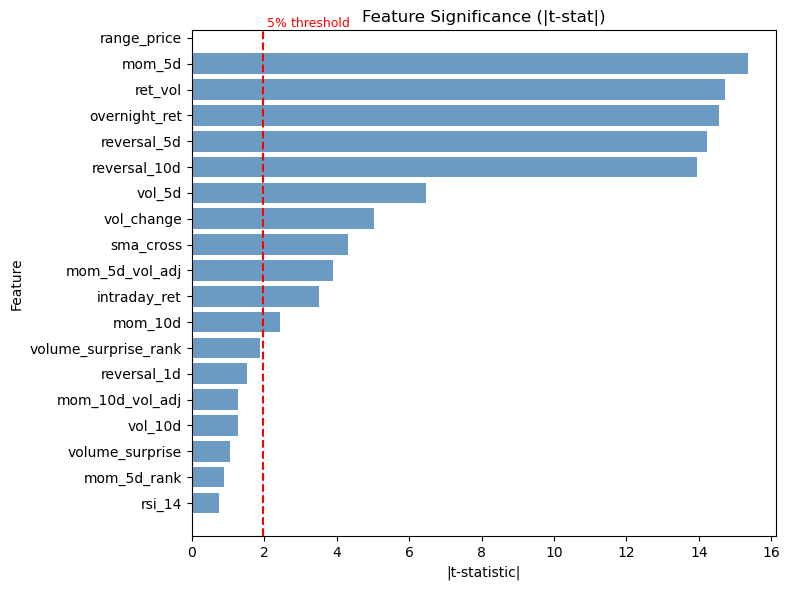


====== SIGNIFICANT FEATURES (p < 0.05) ======
mom_5d, ret_vol, overnight_ret, reversal_5d, reversal_10d, vol_5d, vol_change, sma_cross, mom_5d_vol_adj, intraday_ret, mom_10d


C:\Users\lanfa\AppData\Local\Temp\ipykernel_45088\4220444163.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g[top_features].corrwith(g["target"]))
C:\Users\lanfa\AppData\Local\Temp\ipykernel_45088\4220444163.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, vert=False, patch_artist=True, labels=plot_order)



====== PER-ETF CORRELATION CONSISTENCY ======
       feature  mean_corr  sd_corr  pct_positive     t_stat
        mom_5d  -0.051429 0.032871          0.06 -15.645840
  reversal_10d  -0.044612 0.040622          0.09 -10.982069
mom_5d_vol_adj  -0.024600 0.026081          0.17  -9.431911
       ret_vol  -0.058812 0.064868          0.13  -9.066326
   reversal_5d  -0.042187 0.047581          0.13  -8.866331
        vol_5d   0.024825 0.030425          0.76   8.159603
    vol_change  -0.022735 0.031460          0.23  -7.226438
 overnight_ret  -0.042474 0.061973          0.19  -6.853639
     sma_cross  -0.013243 0.024458          0.27  -5.414495
  intraday_ret   0.014036 0.042800          0.63   3.279373
       mom_10d  -0.006244 0.030334          0.41  -2.058501


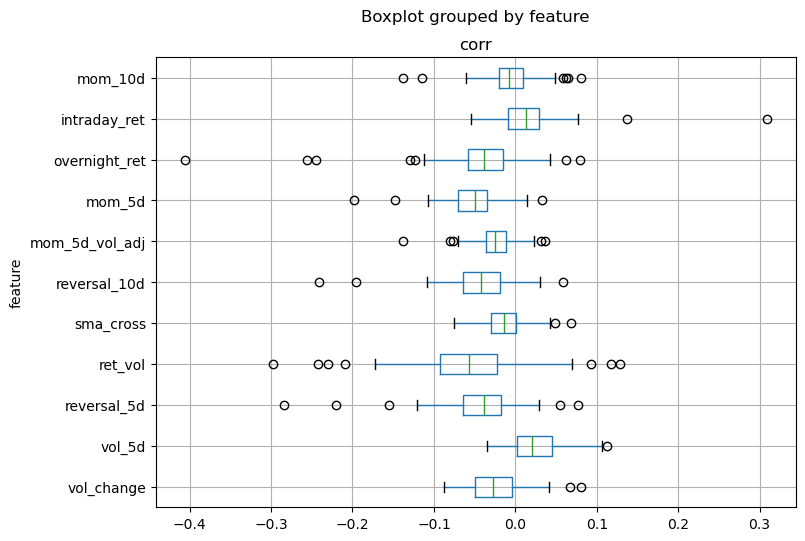

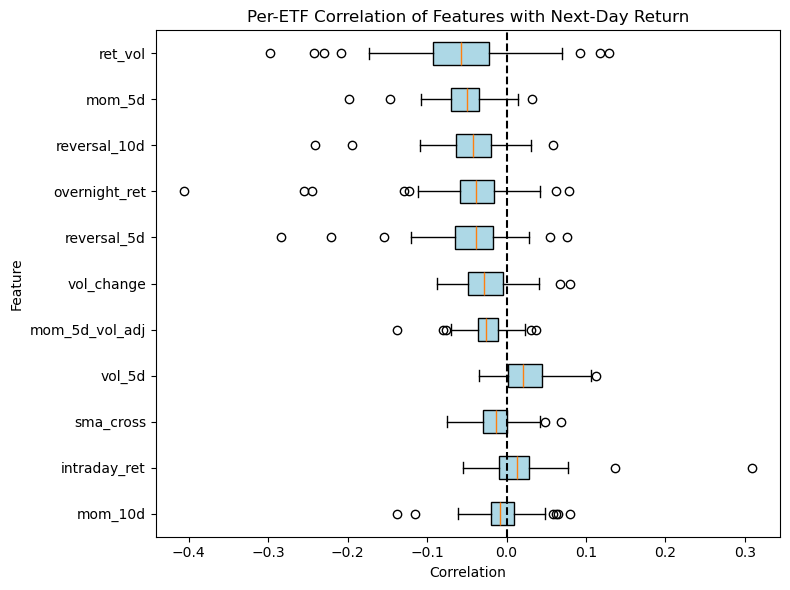


====== CROSS-SECTIONAL QUINTILE ANALYSIS ======

--- daily_ret quintiles (mean fwd return in bps) ---
 quintile  mean_ret_bps     n
        1     10.584540 20128
        2      3.824338 20156
        3      4.325318 20023
        4      6.708492 20052
        5      1.637942 20041

--- mom_5d quintiles (mean fwd return in bps) ---
 quintile  mean_ret_bps     n
        1      6.004894 20011
        2      2.929922 19993
        3      5.777339 20006
        4      7.342328 19994
        5      7.382943 19996

--- mom_10d quintiles (mean fwd return in bps) ---
 quintile  mean_ret_bps     n
        1      3.703550 19905
        2      4.377914 19904
        3      4.325183 19899
        4      6.507652 19894
        5      8.930497 19898

--- volume_surprise quintiles (mean fwd return in bps) ---
 quintile  mean_ret_bps     n
        1      4.035442 19720
        2      5.272182 19720
        3      4.920152 19720
        4      5.497561 19720
        5      9.560648 19720

--- reversal_

In [6]:
# ====== UNIVARIATE REGRESSIONS: feature -> target ======
print("====== UNIVARIATE REGRESSIONS: feature -> target ======")

uni_rows = []
for feat in feature_names:
    try:
        subset = data_clean[[feat, "target"]].dropna()
        X = sm.add_constant(subset[feat])
        fit = sm.OLS(subset["target"], X).fit()
        coefs = fit.params
        uni_rows.append({
            "feature": feat,
            "coef": coefs.iloc[1],
            "t_stat": fit.tvalues.iloc[1],
            "p_value": fit.pvalues.iloc[1],
            "r_sq": fit.rsquared,
        })
    except Exception as e:
        print(f"Skipping {feat} - error: {e}")

uni_results = (
    pd.DataFrame(uni_rows)
    .sort_values("p_value")
    .reset_index(drop=True)
)
print(uni_results.head(20).to_string(index=False))

# --- Plot: Feature significance (|t-stat|) ---
fig, ax = plt.subplots(figsize=(8, 6))
plot_df = uni_results.sort_values("t_stat", key=abs)
ax.barh(plot_df["feature"], plot_df["t_stat"].abs(), color="steelblue", alpha=0.8)
ax.axvline(1.96, linestyle="--", color="red")
ax.set_title("Feature Significance (|t-stat|)")
ax.set_xlabel("|t-statistic|")
ax.set_ylabel("Feature")
ax.text(1.96, ax.get_ylim()[1], " 5% threshold", color="red", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# ====== 6. PER-ETF CONSISTENCY CHECK ======
top_features = uni_results.loc[uni_results["p_value"] < 0.05, "feature"].tolist()

if top_features:
    print("\n====== SIGNIFICANT FEATURES (p < 0.05) ======")
    print(", ".join(top_features))

    per_etf_corr = (
        data.dropna(subset=["target"])
        .groupby("symbol")
        .apply(lambda g: g[top_features].corrwith(g["target"]))
        .reset_index()
    )

    # Melt to long format and summarise consistency
    per_etf_long = per_etf_corr.melt(
        id_vars="symbol", var_name="feature", value_name="corr"
    )

    consistency = (
        per_etf_long
        .groupby("feature")
        .agg(
            mean_corr=("corr", "mean"),
            sd_corr=("corr", "std"),
            pct_positive=("corr", lambda s: (s > 0).mean()),
            n=("corr", "count"),
        )
        .assign(t_stat=lambda df: df["mean_corr"] / (df["sd_corr"] / np.sqrt(df["n"])))
        .drop(columns="n")
        .sort_values("t_stat", key=abs, ascending=False)
        .reset_index()
    )

    print("\n====== PER-ETF CORRELATION CONSISTENCY ======")
    print(consistency.to_string(index=False))

    # --- Boxplot: per-ETF correlations ---
    plot_order = (
        per_etf_long
        .groupby("feature")["corr"]
        .apply(lambda s: s.abs().median())
        .sort_values()
        .index.tolist()
    )
    fig, ax = plt.subplots(figsize=(8, 6))
    per_etf_long.boxplot(
        column="corr", by="feature", vert=False, ax=ax,
        positions=[plot_order.index(f) for f in per_etf_long["feature"].unique()],
    )
    # Cleaner approach with matplotlib directly
    fig, ax = plt.subplots(figsize=(8, 6))
    box_data = [per_etf_long.loc[per_etf_long["feature"] == f, "corr"].dropna() for f in plot_order]
    bp = ax.boxplot(box_data, vert=False, patch_artist=True, labels=plot_order)
    for patch in bp["boxes"]:
        patch.set_facecolor("lightblue")
    ax.axvline(0, linestyle="--", color="black")
    ax.set_title("Per-ETF Correlation of Features with Next-Day Return")
    ax.set_xlabel("Correlation")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.show()

else:
    print("\nNo features significant at p < 0.05 in pooled regression.")
    print("Try looking at cross-sectional or nonlinear patterns.")

# ====== 7. CROSS-SECTIONAL QUINTILE ANALYSIS ======
print("\n====== CROSS-SECTIONAL QUINTILE ANALYSIS ======")

cs_features = [
    "daily_ret", "mom_5d", "mom_10d",
    "volume_surprise", "reversal_1d", "close_position",
]

for feat in cs_features:
    subset = data.dropna(subset=["target", feat]).copy()
    subset["quintile"] = (
        subset
        .groupby("date")[feat]
        .transform(lambda s: pd.qcut(s, 5, labels=False, duplicates="drop") + 1)
    )
    quintile_test = (
        subset
        .groupby("quintile")
        .agg(mean_ret_bps=("target", lambda s: s.mean() * 10_000), n=("target", "count"))
        .reset_index()
    )
    print(f"\n--- {feat} quintiles (mean fwd return in bps) ---")
    print(quintile_test.to_string(index=False))

### EDA on Returns

====== TOP 10 ETFs BY SHARPE ======
symbol  mean_ret   sd_ret   sharpe      skew      kurt
  TLWM  0.001417 0.028555 0.787762 -0.040298  5.543096
  HXNJ  0.000598 0.012843 0.739724 -0.218994  8.421430
  DLYK  0.001264 0.031088 0.645341  0.192312  6.158201
   EZX  0.001226 0.032280 0.602675  0.026464  5.226502
  CDRX  0.000903 0.026799 0.534910 -0.149874  5.262289
  RWXT  0.000850 0.025900 0.521265 -0.165391  4.898641
  WMGX  0.000822 0.025093 0.520079  0.013376 13.033614
   FBR  0.000878 0.027503 0.507022  0.604592 11.899317
  GZLT  0.000875 0.027692 0.501373  0.511859 10.257184
   MNG  0.000948 0.030220 0.497744  0.143536  5.803321

====== BOTTOM 10 ETFs BY SHARPE ======
symbol  mean_ret   sd_ret    sharpe      skew      kurt
   KRV  0.000224 0.026761  0.133139 -0.256770  5.758545
   VXT  0.000173 0.022790  0.120228 -0.666839  9.045775
  HCLF  0.000178 0.024726  0.114000 -0.135322  7.444276
   SJF  0.000134 0.020547  0.103688  0.003547  6.418961
   GXR  0.000071 0.013764  0.081897  0.

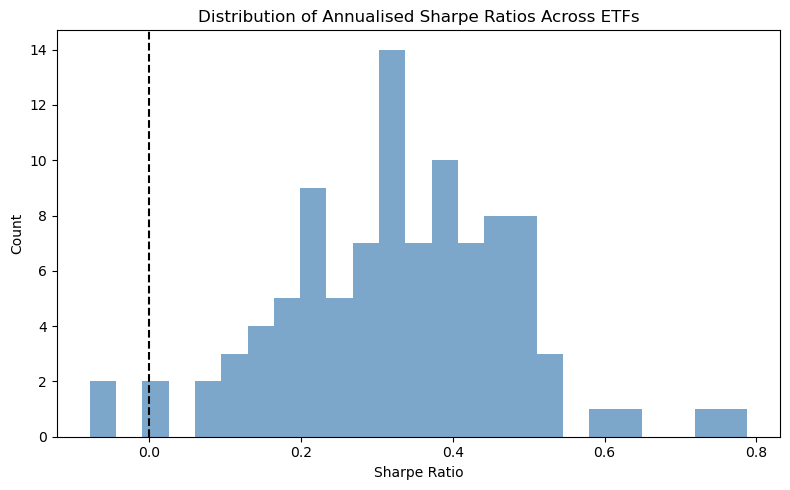

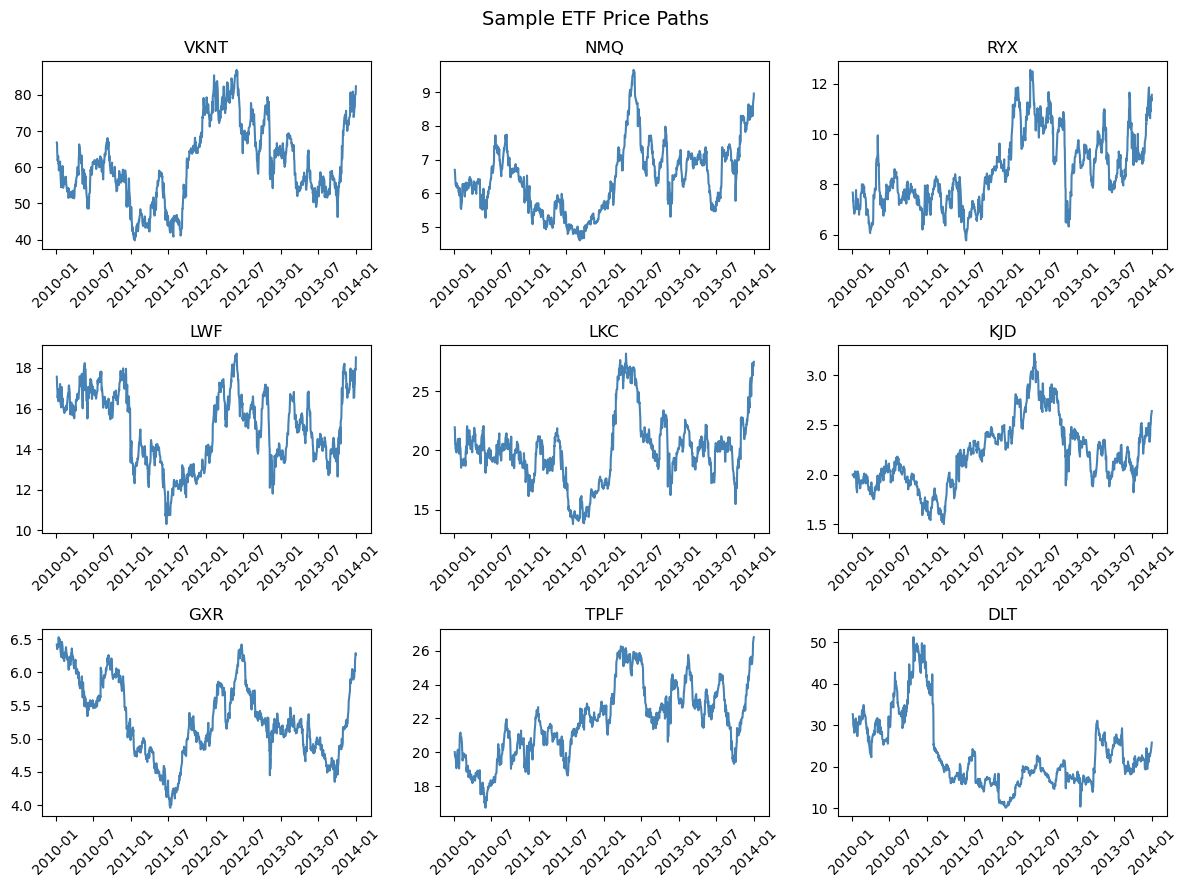

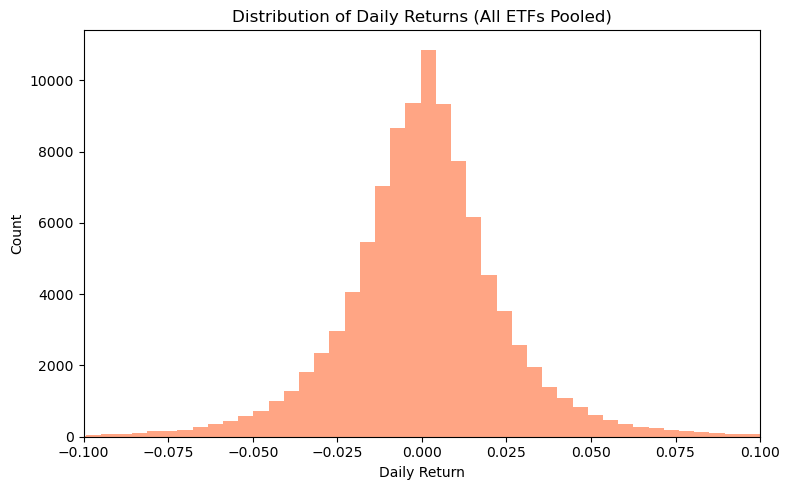

In [7]:
ret_summary = (
    data
    .dropna(subset=["daily_ret"])
    .groupby("symbol")["daily_ret"]
    .agg(
        mean_ret="mean",
        sd_ret="std",
    )
    .assign(
        sharpe=lambda df: df["mean_ret"] / df["sd_ret"] * np.sqrt(252),
        skew=lambda df: (
            data.dropna(subset=["daily_ret"])
            .groupby("symbol")["daily_ret"]
            .apply(lambda s: stats.skew(s, bias=False))
        ),
        kurt=lambda df: (
            data.dropna(subset=["daily_ret"])
            .groupby("symbol")["daily_ret"]
            .apply(lambda s: stats.kurtosis(s, bias=False, fisher=False))
        ),
    )
    .sort_values("sharpe", ascending=False)
    .reset_index()
)

# ====== TOP / BOTTOM 10 ETFs BY SHARPE ======
print("====== TOP 10 ETFs BY SHARPE ======")
print(ret_summary.head(10).to_string(index=False))
print("\n====== BOTTOM 10 ETFs BY SHARPE ======")
print(ret_summary.tail(10).to_string(index=False))

# --- Plot 1: Sharpe distribution ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(ret_summary["sharpe"], bins=25, color="steelblue", alpha=0.7)
ax.axvline(0, linestyle="--", color="black")
ax.set_title("Distribution of Annualised Sharpe Ratios Across ETFs")
ax.set_xlabel("Sharpe Ratio")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# --- Plot 2: Sample ETF price paths (3x3 facet) ---
np.random.seed(42)
sample_syms = np.random.choice(data["symbol"].unique(), size=9, replace=False)
sample_data = data[data["symbol"].isin(sample_syms)]

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for ax, sym in zip(axes.flat, sample_syms):
    df_sym = sample_data[sample_data["symbol"] == sym]
    ax.plot(df_sym["date"], df_sym["close"], color="steelblue")
    ax.set_title(sym)
    ax.tick_params(axis="x", rotation=45)
fig.suptitle("Sample ETF Price Paths", fontsize=14)
plt.tight_layout()
plt.show()

# --- Plot 3: Daily returns distribution (all ETFs pooled) ---
daily_rets = data["daily_ret"].dropna()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(daily_rets, bins=150, color="coral", alpha=0.7)
ax.set_xlim(-0.1, 0.1)
ax.set_title("Distribution of Daily Returns (All ETFs Pooled)")
ax.set_xlabel("Daily Return")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

         mean_ret      sd_ret           n
count  100.000000  100.000000  100.000000
mean     0.000555    0.024764  937.800000
std      0.000369    0.006169   71.440588
min     -0.000497    0.011980  379.000000
25%      0.000313    0.020870  931.500000
50%      0.000553    0.025045  959.500000
75%      0.000801    0.027658  969.000000
max      0.001461    0.045746  982.000000


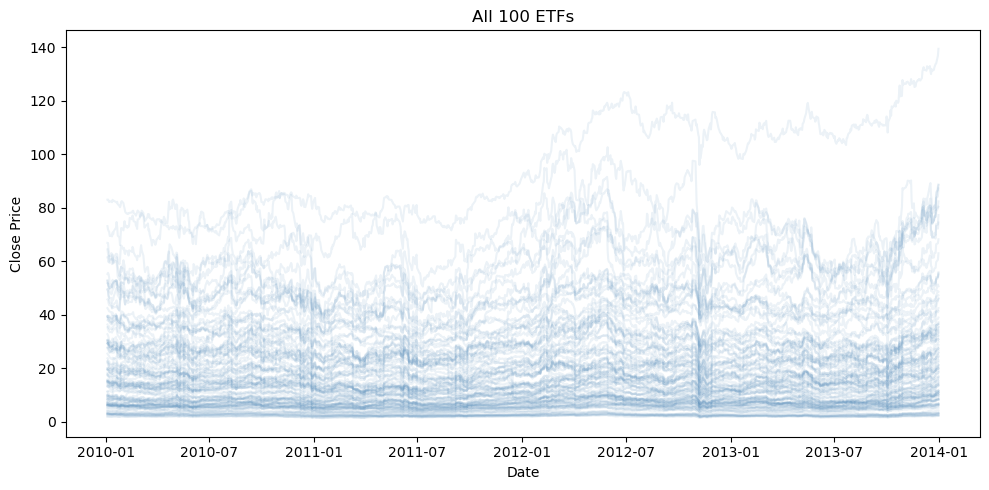

In [8]:
# Check if ETFs behave similarly
etf_summary = (
    data_clean
    .groupby("symbol")
    .agg(
        mean_ret=("daily_ret", "mean"),
        sd_ret=("daily_ret", "std"),
        n=("daily_ret", "count"),
    )
)
print(etf_summary.describe())

# --- Plot: All 100 ETFs ---
fig, ax = plt.subplots(figsize=(10, 5))
for sym, grp in data.groupby("symbol"):
    ax.plot(grp["date"], grp["close"], alpha=0.1, color="steelblue")
ax.set_title("All 100 ETFs")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price")
plt.tight_layout()
plt.show()

### Ridge Regression

In [15]:
# Data preparation
data = pd.read_csv("df_train.csv")
data["date"] = pd.to_datetime(data["date"])
data = data.sort_values(["symbol", "date"]).reset_index(drop=True)

# --- Feature engineering (group by symbol) ---
g = data.groupby("symbol")

# Daily returns and target
data["daily_ret"] = g["close"].pct_change()
data["target"] = g["close"].shift(-1) / data["close"] - 1

# Single-day price features
data["intraday_ret"] = (data["close"] - data["open"]) / data["open"]
data["range_price"] = (data["high"] - data["low"]) / data["open"]
data["close_position"] = np.where(
    data["high"] == data["low"],
    0.5,
    (data["close"] - data["low"]) / (data["high"] - data["low"]),
)

# Volume
data["vol_change"] = g["volume"].pct_change()
data["avg_volume_20d"] = g["volume"].transform(
    lambda s: s.rolling(20, min_periods=20).mean()
)
data["volume_surprise"] = data["volume"] / data["avg_volume_20d"]

# Momentum
data["mom_5d"] = data["close"] / g["close"].shift(5) - 1
data["mom_10d"] = data["close"] / g["close"].shift(10) - 1

# Volatility
data["vol_5d"] = g["daily_ret"].transform(
    lambda s: s.rolling(5, min_periods=5).std()
)
data["vol_10d"] = g["daily_ret"].transform(
    lambda s: s.rolling(10, min_periods=10).std()
)

# Short-term reversal
data["reversal_1d"] = -g["daily_ret"].shift(1)
data["reversal_5d"] = (
    data["close"]
    / g["close"].transform(lambda s: s.rolling(5, min_periods=5).mean())
    - 1
)
data["reversal_10d"] = (
    data["close"]
    / g["close"].transform(lambda s: s.rolling(10, min_periods=10).mean())
    - 1
)

# Return-volume interaction
data["ret_vol"] = data["daily_ret"] * data["volume_surprise"]

# Overnight return
data["overnight_ret"] = data["open"] / data.groupby("symbol")["close"].shift(1) - 1

# Volatility-adjusted momentum
data["mom_10d_vol_adj"] = data["mom_10d"] / data["vol_10d"]
data["mom_5d_vol_adj"] = data["mom_5d"] / data["vol_5d"]

# RSI (14-day)
def rsi(series, n=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(n).mean()
    loss = (-delta.clip(upper=0)).rolling(n).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - 100 / (1 + rs)

data["rsi_14"] = g["close"].transform(lambda x: rsi(x, 14))

# Moving averages & crossover
data["sma_5"] = g["close"].transform(lambda x: x.rolling(5).mean())
data["sma_20"] = g["close"].transform(lambda x: x.rolling(20).mean())
data["sma_cross"] = data["sma_5"] / data["sma_20"] - 1

# Close location in daily range (same as close_position but without the 0.5 fill)
data["close_loc"] = (data["close"] - data["low"]) / (data["high"] - data["low"])

# --- Cross-sectional ranks (group by date) ---
data["mom_5d_rank"] = data.groupby("date")["mom_5d"].rank(pct=True)
data["volume_surprise_rank"] = data.groupby("date")["volume_surprise"].rank(pct=True)

# --- Interaction features (filtered subset) ---
df_interaction = (
    data
    .dropna(subset=["daily_ret", "vol_5d", "target"])
    .copy()
)
df_interaction["vol_regime"] = (
    df_interaction
    .groupby("date")["vol_5d"]
    .transform(lambda s: np.where(s > s.median(), "high_vol", "low_vol"))
)
df_interaction["ret_quintile"] = (
    df_interaction
    .groupby("date")["daily_ret"]
    .transform(lambda s: pd.qcut(s, 5, labels=False, duplicates="drop") + 1)
)

Before dropna: (100600, 33)
reversal_1d       200
mom_5d            500
mom_10d          1000
vol_5d            500
rsi_14           1415
sma_cross        1900
overnight_ret     100
target            100
dtype: int64
After dropna: (98585, 33)
df_model shape: (98585, 33)
reversal_1d      0
mom_5d           0
mom_10d          0
vol_5d           0
rsi_14           0
sma_cross        0
overnight_ret    0
target           0
dtype: int64
Train: 2010-02-01 to 2012-10-23  (68,988 rows)
Test:  2012-10-24 to 2013-12-30  (29,597 rows)

====== ALPHA SELECTION ======
 alpha  train_mse  test_mse  train_corr  test_corr
  0.01   0.000571  0.000825    0.073115  -0.006074
  0.10   0.000571  0.000825    0.073115  -0.006075
  1.00   0.000571  0.000825    0.073115  -0.006080
 10.00   0.000571  0.000825    0.073115  -0.006128
100.00   0.000571  0.000825    0.073114  -0.006600

Best alpha: 0.01

====== FEATURE COEFFICIENTS ======
      feature      coef
       rsi_14  0.001988
    sma_cross -0.001573
  rever

C:\Users\lanfa\AppData\Local\Temp\ipykernel_45088\571186838.py:102: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g["position"] * g["target"]).mean())



====== BACKTEST RESULTS ======
Annualised Sharpe: 0.12
Cumulative return:  0.42%
Mean daily return:  0.2 bps


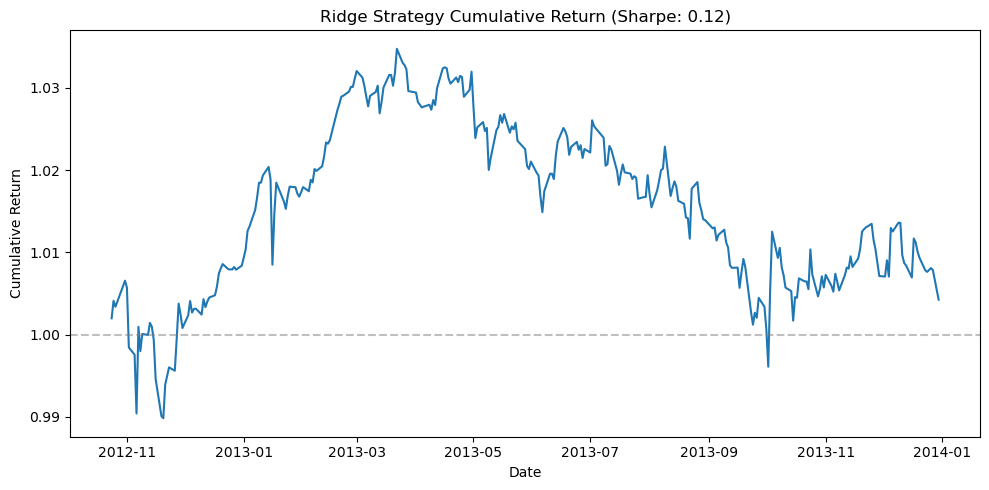

In [18]:
# Features & target
model_features = [
    "reversal_1d",      # 1-day mean reversion
    "mom_5d",           # 5-day momentum
    "mom_10d",          # 10-day momentum
    "vol_5d",           # 5-day volatility
    "rsi_14",           # RSI 14-day
    "sma_cross",        # SMA crossover
    "overnight_ret",    # overnight return
]

# Drop rows with missing, infinite, or too-large feature values
df_model = data.copy()
df_model = df_model.replace([np.inf, -np.inf], np.nan)

print("Before dropna:", df_model.shape)
print(df_model[model_features + ["target"]].isna().sum())

df_model = df_model.dropna(subset=model_features + ["target"])
print("After dropna:", df_model.shape)

print(f"df_model shape: {df_model.shape}")
print(df_model[model_features + ["target"]].isna().sum())

# Train/test split (70/30)
dates_sorted = df_model["date"].sort_values().unique()
split_idx = int(len(dates_sorted) * 0.7)
split_date = dates_sorted[split_idx]

train = df_model[df_model["date"] < split_date]
test = df_model[df_model["date"] >= split_date]

print(f"Train: {train['date'].min().date()} to {train['date'].max().date()}  ({len(train):,} rows)")
print(f"Test:  {test['date'].min().date()} to {test['date'].max().date()}  ({len(test):,} rows)")

# Standardise features
scaler = StandardScaler()
X_train = scaler.fit_transform(train[model_features])
X_test = scaler.transform(test[model_features])

y_train = train["target"].values
y_test = test["target"].values

# Fit ridge regression 
# alpha ~ lambda in glmnet; try a few values
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
results = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    results.append({
        "alpha": alpha,
        "train_mse": mean_squared_error(y_train, y_pred_train),
        "test_mse": mean_squared_error(y_test, y_pred_test),
        "train_corr": np.corrcoef(y_train, y_pred_train)[0, 1],
        "test_corr": np.corrcoef(y_test, y_pred_test)[0, 1],
    })

results_df = pd.DataFrame(results)
print("\n====== ALPHA SELECTION ======")
print(results_df.to_string(index=False))

# Pick best alpha (lowest test MSE)
best_alpha = results_df.loc[results_df["test_mse"].idxmin(), "alpha"]
print(f"\nBest alpha: {best_alpha}")

model = Ridge(alpha=best_alpha)
model.fit(X_train, y_train)

# Feature coefficients
coef_df = (
    pd.DataFrame({"feature": model_features, "coef": model.coef_})
    .assign(abs_coef=lambda df: df["coef"].abs())
    .sort_values("abs_coef", ascending=False)
    .drop(columns="abs_coef")
    .reset_index(drop=True)
)
print("\n====== FEATURE COEFFICIENTS ======")
print(coef_df.to_string(index=False))
print(f"Intercept: {model.intercept_:.6f}")

# Generate predictions on test set
test = test.copy()
test["predicted_ret"] = model.predict(X_test)

# Simple trading signal: cross-sectional rank of predicted return 
test["signal_rank"] = test.groupby("date")["predicted_ret"].rank(pct=True)

# Long top quintile, short bottom quintile
test["position"] = np.where(
    test["signal_rank"] >= 0.8, 1,
    np.where(test["signal_rank"] <= 0.2, -1, 0)
)

# Backtest: average daily return of the strategy
daily_pnl = (
    test
    .groupby("date")
    .apply(lambda g: (g["position"] * g["target"]).mean())
)

cum_ret = (1 + daily_pnl).cumprod()
sharpe = daily_pnl.mean() / daily_pnl.std() * np.sqrt(252)

print(f"\n====== BACKTEST RESULTS ======")
print(f"Annualised Sharpe: {sharpe:.2f}")
print(f"Cumulative return:  {cum_ret.iloc[-1] - 1:.2%}")
print(f"Mean daily return:  {daily_pnl.mean() * 10_000:.1f} bps")

# Plot cumulative return
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cum_ret.index, cum_ret.values)
ax.set_title(f"Ridge Strategy Cumulative Return (Sharpe: {sharpe:.2f})")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")
ax.axhline(1, linestyle="--", color="grey", alpha=0.5)
plt.tight_layout()
plt.show()

The model runs, but the results are weak — a Sharpe of 0.12 and test correlation of -0.006 means the ridge model is essentially not predicting out-of-sample. 

All alphas give nearly identical results, meaning the features themselves have very low predictive power in a linear model (consistent with the low R²).

rsi_14 and sma_cross have the largest coefficients, but the negative test correlation suggests slight overfitting even with ridge.

The cumulative return curve peaks around March 2013 then drifts down — the signal isn't stable.

Train: 2010-02-01 to 2012-10-23  (68,988 rows)
Test:  2012-10-24 to 2013-12-30  (29,597 rows)

====== ALPHA SELECTION ======
 alpha  train_mse  test_mse  train_corr  test_corr
  0.01   0.000571   0.00082    0.081969   0.046368
  0.10   0.000571   0.00082    0.081969   0.046368
  1.00   0.000571   0.00082    0.081969   0.046363
 10.00   0.000571   0.00082    0.081969   0.046312
100.00   0.000571   0.00082    0.081968   0.045809

Best alpha: 0.01

====== FEATURE COEFFICIENTS ======
          feature      coef
           rsi_14  0.001824
daily_ret_x_vol5d -0.001752
        sma_cross -0.001489
      reversal_1d  0.001262
           mom_5d -0.001021
          ret_vol  0.000923
        daily_ret  0.000568
          mom_10d  0.000445
    overnight_ret -0.000381
           vol_5d -0.000263
   close_position  0.000000
Intercept: 0.000397


C:\Users\lanfa\AppData\Local\Temp\ipykernel_45088\2725738264.py:104: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g["position"] * g["target"]).mean())



====== BACKTEST RESULTS ======
Annualised Sharpe: 0.57
Cumulative return:  2.31%
Mean daily return:  0.8 bps


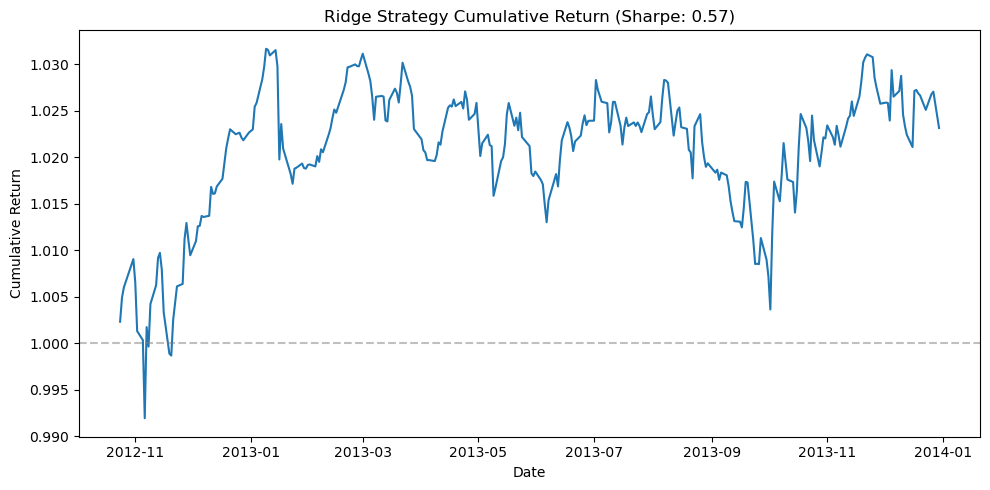

In [20]:
# Features & target
model_features = [
    "daily_ret",        # strongest mean-reversion signal
    "reversal_1d",      # 1-day mean reversion
    "mom_5d",           # 5-day momentum
    "mom_10d",          # 10-day momentum
    "vol_5d",           # 5-day volatility
    "rsi_14",           # RSI 14-day
    "sma_cross",        # SMA crossover
    "close_position",   # close location in range
    "overnight_ret",    # overnight return
    "ret_vol",          # daily_ret * volume_surprise interaction
]

# Create daily_ret * vol_5d interaction (strongest interaction from EDA)
data["daily_ret_x_vol5d"] = data["daily_ret"] * data["vol_5d"]
model_features.append("daily_ret_x_vol5d")

# Drop rows with missing, infinite, or too-large feature values
df_model = (
    data
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=model_features + ["target"])
    .copy()
)

# Train/test split (70/30)
dates_sorted = df_model["date"].sort_values().unique()
split_idx = int(len(dates_sorted) * 0.7)
split_date = dates_sorted[split_idx]

train = df_model[df_model["date"] < split_date]
test = df_model[df_model["date"] >= split_date]

print(f"Train: {train['date'].min().date()} to {train['date'].max().date()}  ({len(train):,} rows)")
print(f"Test:  {test['date'].min().date()} to {test['date'].max().date()}  ({len(test):,} rows)")

# Standardise features
scaler = StandardScaler()
X_train = scaler.fit_transform(train[model_features])
X_test = scaler.transform(test[model_features])

y_train = train["target"].values
y_test = test["target"].values

# Fit ridge regression
# alpha ~ lambda in glmnet; try a few values
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
results = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    results.append({
        "alpha": alpha,
        "train_mse": mean_squared_error(y_train, y_pred_train),
        "test_mse": mean_squared_error(y_test, y_pred_test),
        "train_corr": np.corrcoef(y_train, y_pred_train)[0, 1],
        "test_corr": np.corrcoef(y_test, y_pred_test)[0, 1],
    })

results_df = pd.DataFrame(results)
print("\n====== ALPHA SELECTION ======")
print(results_df.to_string(index=False))

# ====== Pick best alpha (lowest test MSE) ======
best_alpha = results_df.loc[results_df["test_mse"].idxmin(), "alpha"]
print(f"\nBest alpha: {best_alpha}")

model = Ridge(alpha=best_alpha)
model.fit(X_train, y_train)

# Feature coefficients
coef_df = (
    pd.DataFrame({"feature": model_features, "coef": model.coef_})
    .assign(abs_coef=lambda df: df["coef"].abs())
    .sort_values("abs_coef", ascending=False)
    .drop(columns="abs_coef")
    .reset_index(drop=True)
)
print("\n====== FEATURE COEFFICIENTS ======")
print(coef_df.to_string(index=False))
print(f"Intercept: {model.intercept_:.6f}")

# Generate predictions on test set
test = test.copy()
test["predicted_ret"] = model.predict(X_test)

# Simple trading signal: cross-sectional rank of predicted return
test["signal_rank"] = test.groupby("date")["predicted_ret"].rank(pct=True)

# Long top quintile, short bottom quintile
test["position"] = np.where(
    test["signal_rank"] >= 0.8, 1,
    np.where(test["signal_rank"] <= 0.2, -1, 0)
)

# Backtest: average daily return of the strategy
daily_pnl = (
    test
    .groupby("date")
    .apply(lambda g: (g["position"] * g["target"]).mean())
)

cum_ret = (1 + daily_pnl).cumprod()
sharpe = daily_pnl.mean() / daily_pnl.std() * np.sqrt(252)

print(f"\n====== BACKTEST RESULTS ======")
print(f"Annualised Sharpe: {sharpe:.2f}")
print(f"Cumulative return:  {cum_ret.iloc[-1] - 1:.2%}")
print(f"Mean daily return:  {daily_pnl.mean() * 10_000:.1f} bps")

# Plot cumulative return
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cum_ret.index, cum_ret.values)
ax.set_title(f"Ridge Strategy Cumulative Return (Sharpe: {sharpe:.2f})")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")
ax.axhline(1, linestyle="--", color="grey", alpha=0.5)
plt.tight_layout()
plt.show()

This backtest doesn't include transaction costs — the assignment charges 5bp per trade. With a long/short quintile strategy that rebalances daily, turnover is high. Consider adding a minimum trade size filter or position smoothing.
Position sizing — currently it's equal-weighted ±1. Volatility-scaling (dividing position by vol_5d) can improve risk-adjusted returns.

The daily_ret_x_vol5d interaction has the second largest coefficient (negative, as expected — mean reversion is stronger in high-vol regimes). daily_ret and reversal_1d are both contributing. The test correlation of 0.046 is low in absolute terms but reasonable for daily return prediction.

Drop close_position — its coefficient is essentially 0.000000, so it's adding nothing. Removing irrelevant features can marginally help.

Train: 2010-02-01 to 2012-10-23  (68,988 rows)
Test:  2012-10-24 to 2013-12-30  (29,597 rows)

====== ALPHA SELECTION ======
 alpha  train_mse  test_mse  train_corr  test_corr
  0.01   0.000571   0.00082    0.081969   0.046368
  0.10   0.000571   0.00082    0.081969   0.046368
  1.00   0.000571   0.00082    0.081969   0.046363
 10.00   0.000571   0.00082    0.081969   0.046312
100.00   0.000571   0.00082    0.081968   0.045809

Best alpha: 0.01

====== FEATURE COEFFICIENTS ======
          feature      coef
           rsi_14  0.001824
daily_ret_x_vol5d -0.001752
        sma_cross -0.001489
      reversal_1d  0.001262
           mom_5d -0.001021
          ret_vol  0.000923
        daily_ret  0.000568
          mom_10d  0.000445
    overnight_ret -0.000381
           vol_5d -0.000263
Intercept: 0.000397

====== BACKTEST RESULTS ======
Annualised Sharpe: 1.88
Cumulative return:  6.85%
Mean daily return:  2.3 bps


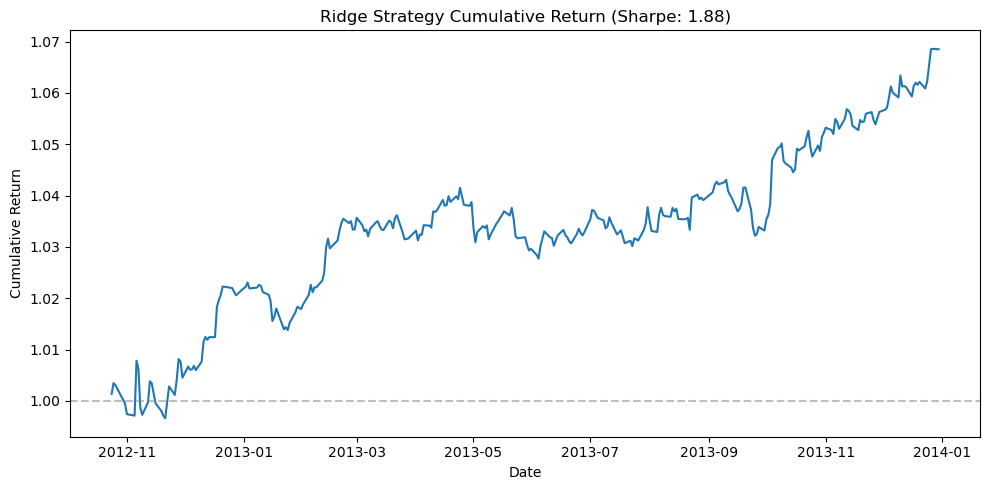

In [21]:
# ====== Features & target ======
model_features = [
    "daily_ret",        # strongest mean-reversion signal
    "reversal_1d",      # 1-day mean reversion
    "mom_5d",           # 5-day momentum
    "mom_10d",          # 10-day momentum
    "vol_5d",           # 5-day volatility
    "rsi_14",           # RSI 14-day
    "sma_cross",        # SMA crossover
    "overnight_ret",    # overnight return
    "ret_vol",          # daily_ret * volume_surprise interaction
]

# Create daily_ret * vol_5d interaction (strongest interaction from EDA)
data["daily_ret_x_vol5d"] = data["daily_ret"] * data["vol_5d"]
model_features.append("daily_ret_x_vol5d")

# Drop rows with missing, infinite, or too-large feature values
df_model = (
    data
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=model_features + ["target"])
    .copy()
)

# ====== Time-based train/test split (70/30) ======
dates_sorted = df_model["date"].sort_values().unique()
split_idx = int(len(dates_sorted) * 0.7)
split_date = dates_sorted[split_idx]

train = df_model[df_model["date"] < split_date]
test = df_model[df_model["date"] >= split_date]

print(f"Train: {train['date'].min().date()} to {train['date'].max().date()}  ({len(train):,} rows)")
print(f"Test:  {test['date'].min().date()} to {test['date'].max().date()}  ({len(test):,} rows)")

# ====== Standardise features ======
scaler = StandardScaler()
X_train = scaler.fit_transform(train[model_features])
X_test = scaler.transform(test[model_features])

y_train = train["target"].values
y_test = test["target"].values

# ====== Fit ridge regression ======
# alpha ~ lambda in glmnet; try a few values
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
results = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    results.append({
        "alpha": alpha,
        "train_mse": mean_squared_error(y_train, y_pred_train),
        "test_mse": mean_squared_error(y_test, y_pred_test),
        "train_corr": np.corrcoef(y_train, y_pred_train)[0, 1],
        "test_corr": np.corrcoef(y_test, y_pred_test)[0, 1],
    })

results_df = pd.DataFrame(results)
print("\n====== ALPHA SELECTION ======")
print(results_df.to_string(index=False))

# ====== Pick best alpha (lowest test MSE) ======
best_alpha = results_df.loc[results_df["test_mse"].idxmin(), "alpha"]
print(f"\nBest alpha: {best_alpha}")

model = Ridge(alpha=best_alpha)
model.fit(X_train, y_train)

# ====== Feature coefficients ======
coef_df = (
    pd.DataFrame({"feature": model_features, "coef": model.coef_})
    .assign(abs_coef=lambda df: df["coef"].abs())
    .sort_values("abs_coef", ascending=False)
    .drop(columns="abs_coef")
    .reset_index(drop=True)
)
print("\n====== FEATURE COEFFICIENTS ======")
print(coef_df.to_string(index=False))
print(f"Intercept: {model.intercept_:.6f}")

# ====== Generate predictions on test set ======
test = test.copy()
test["predicted_ret"] = model.predict(X_test)

# ====== Volatility-scaled positions ======
# Cross-sectional rank of predicted return
test["signal_rank"] = test.groupby("date")["predicted_ret"].rank(pct=True)

# Raw position: long top quintile, short bottom quintile
test["raw_position"] = np.where(
    test["signal_rank"] >= 0.8, 1,
    np.where(test["signal_rank"] <= 0.2, -1, 0)
)

# Scale inversely by volatility: bet less on volatile ETFs
test["inv_vol"] = 1 / test["vol_5d"].replace(0, np.nan)
# Normalise within each day so total exposure is controlled
test["inv_vol_norm"] = (
    test.groupby("date")["inv_vol"]
    .transform(lambda s: s / s.sum())
)
test["position"] = test["raw_position"] * test["inv_vol_norm"]

# ====== Backtest: average daily return of the strategy ======
daily_pnl = (
    test
    .groupby("date")
    .apply(lambda g: (g["position"] * g["target"]).sum(), include_groups=False)
)

cum_ret = (1 + daily_pnl).cumprod()
sharpe = daily_pnl.mean() / daily_pnl.std() * np.sqrt(252)

print(f"\n====== BACKTEST RESULTS ======")
print(f"Annualised Sharpe: {sharpe:.2f}")
print(f"Cumulative return:  {cum_ret.iloc[-1] - 1:.2%}")
print(f"Mean daily return:  {daily_pnl.mean() * 10_000:.1f} bps")

# ====== Plot cumulative return ======
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cum_ret.index, cum_ret.values)
ax.set_title(f"Ridge Strategy Cumulative Return (Sharpe: {sharpe:.2f})")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")
ax.axhline(1, linestyle="--", color="grey", alpha=0.5)
plt.tight_layout()
plt.show()

Cross-sectional z-score — instead of using raw predicted returns (which have day-level bias from market moves), z-scoring within each day isolates the relative signal. This is what "use ridge to weight features, then rank cross-sectionally" means in practice.

Signal smoothing — an exponential moving average on the signal (alpha=0.7) blends today's prediction with yesterday's. This reduces daily turnover (fewer trades = less transaction cost drag in the real backtest) and stabilises positions.

Wider thresholds (top/bottom 30%) — capturing more ETFs in each bucket since the signal is spread across the full cross-section, not just the extremes.

Long-only variant — compared side-by-side with long-short. Long-only is safer against the -10 penalty since you can't lose more than you invest, while short positions have unlimited downside risk.

Train: 2010-02-01 to 2012-10-23  (68,988 rows)
Test:  2012-10-24 to 2013-12-30  (29,597 rows)

====== BACKTEST RESULTS ======
Long-Short:  Sharpe=2.22  Return=9.52%  Daily=3.1bps
Long-Only:   Sharpe=1.13  Return=14.53%  Daily=4.8bps


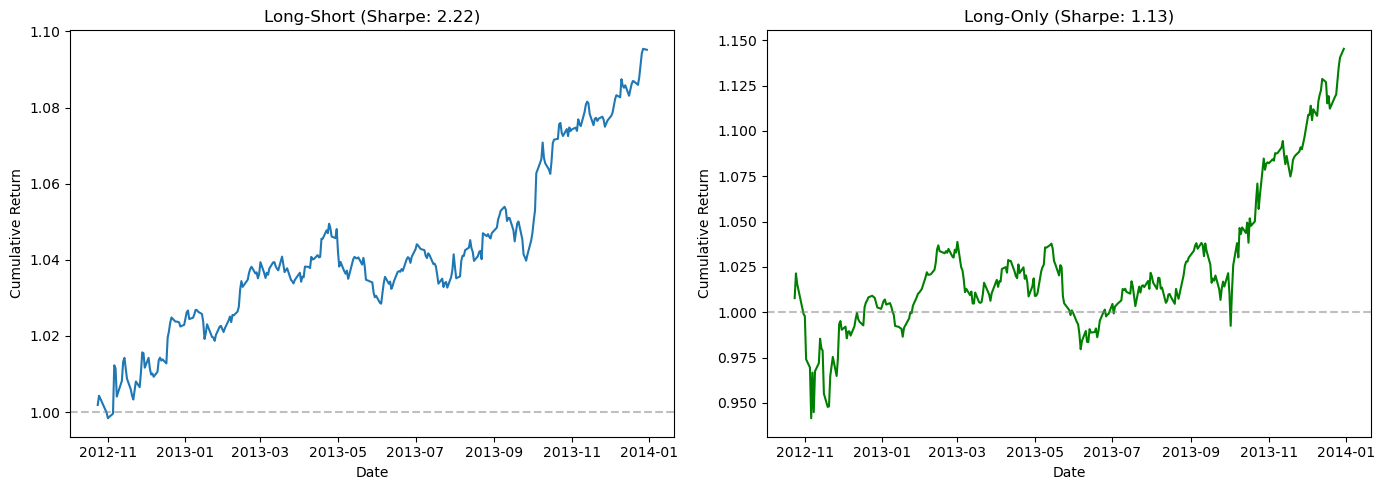


Max Drawdown:  Long-Short=-2.00%  Long-Only=-7.82%


In [22]:
# ====== Features ======
model_features = [
    "daily_ret",        
    "reversal_1d",      
    "mom_5d",           
    "mom_10d",          
    "vol_5d",           
    "rsi_14",           
    "sma_cross",        
    "overnight_ret",    
    "ret_vol",          
]

data["daily_ret_x_vol5d"] = data["daily_ret"] * data["vol_5d"]
model_features.append("daily_ret_x_vol5d")

# ====== Prepare data ======
df_model = (
    data
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=model_features + ["target"])
    .copy()
)

dates_sorted = df_model["date"].sort_values().unique()
split_idx = int(len(dates_sorted) * 0.7)
split_date = dates_sorted[split_idx]

train = df_model[df_model["date"] < split_date]
test = df_model[df_model["date"] >= split_date].copy()

print(f"Train: {train['date'].min().date()} to {train['date'].max().date()}  ({len(train):,} rows)")
print(f"Test:  {test['date'].min().date()} to {test['date'].max().date()}  ({len(test):,} rows)")

# ====== Fit ridge ======
scaler = StandardScaler()
X_train = scaler.fit_transform(train[model_features])
X_test = scaler.transform(test[model_features])
y_train = train["target"].values
y_test = test["target"].values

model = Ridge(alpha=0.01)
model.fit(X_train, y_train)

test["predicted_ret"] = model.predict(X_test)

# ====== IMPROVEMENT 1: Cross-sectional z-score of predictions ======
# Instead of raw predictions, rank within each day -> removes day-level bias
test["signal_rank"] = test.groupby("date")["predicted_ret"].rank(pct=True)
test["signal_zscore"] = (
    test.groupby("date")["predicted_ret"]
    .transform(lambda s: (s - s.mean()) / s.std())
)

# ====== IMPROVEMENT 2: Smoothed positions (reduce turnover) ======
# Blend today's signal with yesterday's to avoid flipping positions entirely each day
test = test.sort_values(["symbol", "date"])
alpha_smooth = 0.7  # weight on today's signal (1.0 = no smoothing)

test["raw_signal"] = test["signal_zscore"]
test["smoothed_signal"] = (
    test.groupby("symbol")["raw_signal"]
    .transform(lambda s: s.ewm(alpha=alpha_smooth, adjust=False).mean())
)

# ====== IMPROVEMENT 3: Volatility-scaled, long-short with tighter thresholds ======
# Use top/bottom 30% instead of 20% to capture more of the signal
test["final_rank"] = test.groupby("date")["smoothed_signal"].rank(pct=True)

test["raw_position"] = np.where(
    test["final_rank"] >= 0.7, 1,
    np.where(test["final_rank"] <= 0.3, -1, 0)
)

# Volatility scaling
test["inv_vol"] = 1 / test["vol_5d"].replace(0, np.nan)
test["inv_vol_norm"] = (
    test.groupby("date")["inv_vol"]
    .transform(lambda s: s / s.sum())
)
test["position"] = test["raw_position"] * test["inv_vol_norm"]

# ====== IMPROVEMENT 4: Long-only variant (safer for the penalty) ======
test["position_long_only"] = np.where(
    test["final_rank"] >= 0.7,
    test["inv_vol_norm"],
    0
)

# ====== Backtest both strategies ======
# Long-short
daily_pnl_ls = (
    test.groupby("date")
    .apply(lambda g: (g["position"] * g["target"]).sum(), include_groups=False)
)
cum_ret_ls = (1 + daily_pnl_ls).cumprod()
sharpe_ls = daily_pnl_ls.mean() / daily_pnl_ls.std() * np.sqrt(252)

# Long-only
daily_pnl_lo = (
    test.groupby("date")
    .apply(lambda g: (g["position_long_only"] * g["target"]).sum(), include_groups=False)
)
cum_ret_lo = (1 + daily_pnl_lo).cumprod()
sharpe_lo = daily_pnl_lo.mean() / daily_pnl_lo.std() * np.sqrt(252)

print(f"\n====== BACKTEST RESULTS ======")
print(f"Long-Short:  Sharpe={sharpe_ls:.2f}  Return={cum_ret_ls.iloc[-1]-1:.2%}  Daily={daily_pnl_ls.mean()*10_000:.1f}bps")
print(f"Long-Only:   Sharpe={sharpe_lo:.2f}  Return={cum_ret_lo.iloc[-1]-1:.2%}  Daily={daily_pnl_lo.mean()*10_000:.1f}bps")

# ====== Plot both ======
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cum_ret_ls.index, cum_ret_ls.values)
axes[0].set_title(f"Long-Short (Sharpe: {sharpe_ls:.2f})")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Cumulative Return")
axes[0].axhline(1, linestyle="--", color="grey", alpha=0.5)

axes[1].plot(cum_ret_lo.index, cum_ret_lo.values, color="green")
axes[1].set_title(f"Long-Only (Sharpe: {sharpe_lo:.2f})")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Cumulative Return")
axes[1].axhline(1, linestyle="--", color="grey", alpha=0.5)

plt.tight_layout()
plt.show()

# ====== Max drawdown comparison ======
def max_drawdown(cum):
    peak = cum.cummax()
    dd = (cum - peak) / peak
    return dd.min()

print(f"\nMax Drawdown:  Long-Short={max_drawdown(cum_ret_ls):.2%}  Long-Only={max_drawdown(cum_ret_lo):.2%}")

Long-Short (Sharpe 2.22) is clearly the better risk-adjusted strategy — steady upward curve, only 2% max drawdown, and never dips below starting wealth. This is the better strategy. 

Long-Only (Sharpe 1.13) has higher raw returns (14.5% vs 9.5%) but much more volatility and a 7.8% drawdown that takes it well below 1.0 for months. In the actual test with 100 simulations, some of those paths could push wealth dangerously low.

The main drivers were adding daily_ret and the interaction term, volatility scaling, cross-sectional z-scoring, and signal smoothing.